# MMM Demo — end-to-end pipeline (exploration)

Ingestion -> EDA -> feature engineering -> modeling -> results.

This notebook is self-contained (dev-only): the production-ready version of the
shared functions lives in `utils/func.py` and is consumed by `inference/predict.py`.

## 1. Ingestion

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

SPEND_CHANNELS = ["tv_spend", "digital_spend", "ooh_spend"]


In [2]:
df = pd.read_csv("../data/inputs/mmm_demo_sales_media.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()

,date,tv_spend,digital_spend,ooh_spend,sales
0,2024-01-01,8367.27,11441.39,2090.42,42556.97
1,2024-01-08,11341.38,6636.21,4902.85,42869.13
2,2024-01-15,7348.86,8904.67,775.94,41339.50
3,2024-01-22,6580.28,5157.75,1595.85,35018.14
4,2024-01-29,12317.02,9177.58,1903.55,49248.11


## 2. EDA

In [3]:
df.describe()

,date,tv_spend,digital_spend,ooh_spend,sales
count,104,104.000000,104.000000,104.000000,104.000000
mean,2024-12-26 12:00:00,7385.583173,8371.422212,2112.726538,40900.601827
min,2024-01-01 00:00:00,605.510000,681.500000,31.160000,18768.210000
25%,2024-06-29 06:00:00,3865.202500,5100.512500,903.342500,33673.205000
50%,2024-12-26 12:00:00,6610.265000,7572.850000,1648.780000,39473.520000
75%,2025-06-24 18:00:00,9953.032500,10651.327500,2985.677500,48094.117500
max,2025-12-22 00:00:00,24805.110000,29618.520000,9330.050000,73493.710000
std,NaN,4853.118329,5326.765672,1688.539279,10877.557143


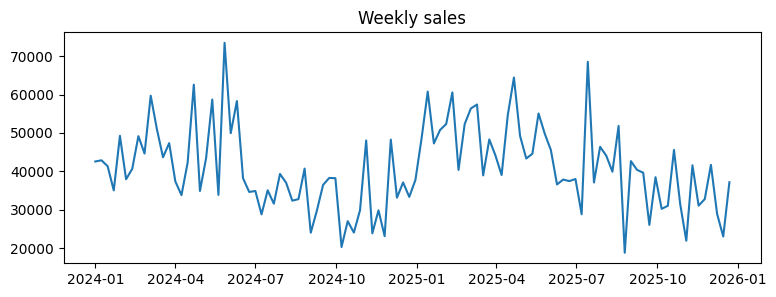

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(df["date"], df["sales"])
ax.set_title("Weekly sales")
plt.show()

## 3. Feature engineering

In [5]:
def apply_adstock(series, decay):
    adstocked = np.zeros(len(series))
    carryover = 0.0
    for i, value in enumerate(series.to_numpy()):
        carryover = value + decay * carryover
        adstocked[i] = carryover
    return adstocked


def engineer_features(df, decay=0.5):
    df = df.copy()
    for channel in SPEND_CHANNELS:
        df[f"{channel}_adstock"] = apply_adstock(df[channel], decay=decay)
    df["trend"] = np.arange(len(df))
    return df


df_features = engineer_features(df, decay=0.5)
feature_cols = [f"{c}_adstock" for c in SPEND_CHANNELS] + ["trend"]
X, y = df_features[feature_cols], df_features["sales"]
X.head()

,tv_spend_adstock,digital_spend_adstock,ooh_spend_adstock,trend
0,8367.270000,11441.390000,2090.4200,0
1,15525.015000,12356.905000,5948.0600,1
2,15111.367500,15083.122500,3749.9700,2
3,14135.963750,12699.311250,3470.8350,3
4,19385.001875,15527.235625,3638.9675,4


## 4. Modeling

In [6]:
model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)
metrics = {"r2": r2_score(y, predictions), "mae": mean_absolute_error(y, predictions)}
metrics

{'r2': 0.6119255814837329, 'mae': 5384.835082809297}

## 5. Write results

In [7]:
results = pd.DataFrame({"date": df["date"], "actual_sales": y, "predicted_sales": predictions})
for feature, coef in zip(X.columns, model.coef_):
    results[f"contribution_{feature}"] = X[feature] * coef

Path("../data/outputs").mkdir(parents=True, exist_ok=True)
Path("../data/model").mkdir(parents=True, exist_ok=True)
results.to_csv("../data/outputs/mmm_demo_results.csv", index=False)
with open("../data/model/mmm_demo_model.pkl", "wb") as f:
    pickle.dump(model, f)
results.head()

,date,actual_sales,predicted_sales,contribution_tv_spend_adstock,contribution_digital_spend_adstock,contribution_ooh_spend_adstock,contribution_trend
0,2024-01-01,42556.97,32197.978263,8046.314711,12633.232169,-387.233017,-0.000000
1,2024-01-08,42869.13,39324.739687,14929.499895,13644.115772,-1101.828925,-52.711455
2,2024-01-15,41339.50,42291.631400,14531.719261,16654.321580,-694.650930,-105.422910
3,2024-01-22,35018.14,38720.507275,13593.730462,14022.190259,-642.943480,-158.134365
4,2024-01-29,49248.11,46806.851382,18641.423758,17144.697680,-674.088635,-210.845820
